# One-subject ROI beta analysis


In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.image import load_img, resample_to_img
from nilearn.masking import apply_mask
from nilearn import plotting


In [2]:
# -----------------------------
# User parameters
# -----------------------------

SAVE_DIR = "/gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLM/results"
PREPROC_DIR = "/gpfs/milgram/scratch60/turk-browne/aa2842/sandbox/auditory-object-scenes-data/preprocessed"
SUBJECT = "pp06"
TASK = "vislocalizer"
SPACE = "T1w"

HARVARD_OXFORD_ROI_DIR = os.path.join(PREPROC_DIR, f"sub-{SUBJECT}", "rois", "harvard-oxford")
ASHS_ROI_DIR = os.path.join(
    PREPROC_DIR, f"sub-{SUBJECT}", "rois", "ASHS_maguire", "final",
    "func_masks", "bin_masks_5B_T1"
)

# Edit these dictionaries to change the analyzed ROIs.
HARVARD_OXFORD_ROIS = {
    "PPA": "Parahippocampal Gyrus, posterior division.nii.gz",  # PHG
    "CG": "Cingulate Gyrus, posterior division.nii.gz",  # RSC
    "LOC": "Lateral Occipital Cortex, superior division.nii.gz",  # OPA
    "IT_ant": "Inferior Temporal Gyrus, anterior division.nii.gz",
    "IT_post": "Inferior Temporal Gyrus, posterior division.nii.gz",
}

# Bilateral/whole ASHS masks only; left and right masks are intentionally omitted.
ASHS_ROIS = {
    "DG": "combined_dentate_gyrus_mask_T1.nii.gz",
    "CA2_3": "combined_ca_2_3_mask_T1.nii.gz",
    "CA1": "combined_ca_1_mask_T1.nii.gz",
    "Subiculum": "combined_subiculum_mask_T1.nii.gz",
    "Uncus": "combined_uncus_mask_T1.nii.gz",
    "PreParasubiculum": "combined_pre_parasubiculum_mask_T1.nii.gz",
    "HPC": "combined_HPC_mask_T1.nii.gz",
}

ROIS = {
    **{code: os.path.join(HARVARD_OXFORD_ROI_DIR, name) for code, name in HARVARD_OXFORD_ROIS.items()},
    **{code: os.path.join(ASHS_ROI_DIR, name) for code, name in ASHS_ROIS.items()},
}

CONDITIONS = {
    "Scenes": "visual_scene",
    "Objects": "visual_object",
    "Scrambled scenes": "visual_scrambled_scene",
}

MASK_THRESHOLD = 0
OUTPUT_DIR = os.path.join(SAVE_DIR, "first_level_glm", f"sub-{SUBJECT}", "roi_beta_analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def format_subject(sub):
    sub = str(sub).strip().replace("sub-", "")
    if not sub.startswith("pp"):
        sub = f"pp{sub}"
    return sub


def condition_effect_path(condition_id):
    sub_bids = f"sub-{format_subject(SUBJECT)}"
    return os.path.join(
        SAVE_DIR,
        "first_level_glm",
        sub_bids,
        "condition",
        condition_id,
        f"{sub_bids}_task-{TASK}_condition-{condition_id}_space-{SPACE}_stat-effect_size.nii.gz",
    )


def roi_mask_path(roi_file_name):
    if os.path.isabs(roi_file_name):
        return roi_file_name
    if not (roi_file_name.endswith(".nii") or roi_file_name.endswith(".nii.gz")):
        roi_file_name = f"{roi_file_name}.nii.gz"
    return os.path.join(ROI_MASK_DIR, roi_file_name)


def make_binary_mask(mask_img, threshold=0):
    mask_data = mask_img.get_fdata()
    mask_data = np.isfinite(mask_data) & (mask_data > threshold)
    return nib.Nifti1Image(mask_data.astype(np.uint8), mask_img.affine, mask_img.header)


def extract_mean_beta(beta_img, roi_path, threshold=0):
    roi_img = load_img(roi_path)
    roi_img = resample_to_img(roi_img, beta_img, interpolation="nearest", force_resample=True, copy_header=True)
    roi_img = make_binary_mask(roi_img, threshold=threshold)

    values = apply_mask(beta_img, roi_img)
    values = values[np.isfinite(values)]

    if values.size == 0:
        raise ValueError(f"No finite voxels found in ROI mask: {roi_path}")

    return float(np.mean(values)), int(values.size)

In [4]:
rows = []
condition_paths = {label: condition_effect_path(condition_id) for label, condition_id in CONDITIONS.items()}
roi_paths = {code: roi_mask_path(file_name) for code, file_name in ROIS.items()}
missing_paths = [path for path in [*condition_paths.values(), *roi_paths.values()] if not os.path.isfile(path)]
if missing_paths:
    raise FileNotFoundError("Missing required GLM or ROI files:\n" + "\n".join(missing_paths))

condition_imgs = {label: load_img(path) for label, path in condition_paths.items()}

for roi_code, roi_file_name in ROIS.items():
    roi_path = roi_paths[roi_code]

    for condition_label, beta_img in condition_imgs.items():
        mean_beta, n_voxels = extract_mean_beta(
            beta_img,
            roi_path,
            threshold=MASK_THRESHOLD,
        )

        rows.append({
            "roi": roi_code,
            "roi_name": os.path.basename(roi_file_name),
            "condition": condition_label,
            "mean_beta": mean_beta,
            "n_voxels": n_voxels,
            "roi_path": roi_path,
        })

results = pd.DataFrame(rows)
results

,roi,roi_name,condition,mean_beta,n_voxels,roi_path
0,PPA,"Parahippocampal Gyrus, posterior division.nii.gz",Scenes,0.447046,1207,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
1,PPA,"Parahippocampal Gyrus, posterior division.nii.gz",Objects,0.086758,1207,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
2,PPA,"Parahippocampal Gyrus, posterior division.nii.gz",Scrambled scenes,0.027455,1207,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
3,CG,"Cingulate Gyrus, posterior division.nii.gz",Scenes,0.320658,3550,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
4,CG,"Cingulate Gyrus, posterior division.nii.gz",Objects,0.089110,3550,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
5,CG,"Cingulate Gyrus, posterior division.nii.gz",Scrambled scenes,-0.014161,3550,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
6,LOC,"Lateral Occipital Cortex, superior division.ni...",Scenes,0.441830,16900,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
7,LOC,"Lateral Occipital Cortex, superior division.ni...",Objects,0.235939,16900,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
8,LOC,"Lateral Occipital Cortex, superior division.ni...",Scrambled scenes,0.091828,16900,/gpfs/milgram/scratch60/turk-browne/aa2842/san...
9,IT_ant,"Inferior Temporal Gyrus, anterior division.nii.gz",Scenes,0.279316,1184,/gpfs/milgram/scratch60/turk-browne/aa2842/san...


In [5]:
csv_path = os.path.join(OUTPUT_DIR, f"sub-{format_subject(SUBJECT)}_roi_condition_betas.csv")
results.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

Saved CSV: /gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLM/results/first_level_glm/sub-pp06/roi_beta_analysis/sub-pp06_roi_condition_betas.csv


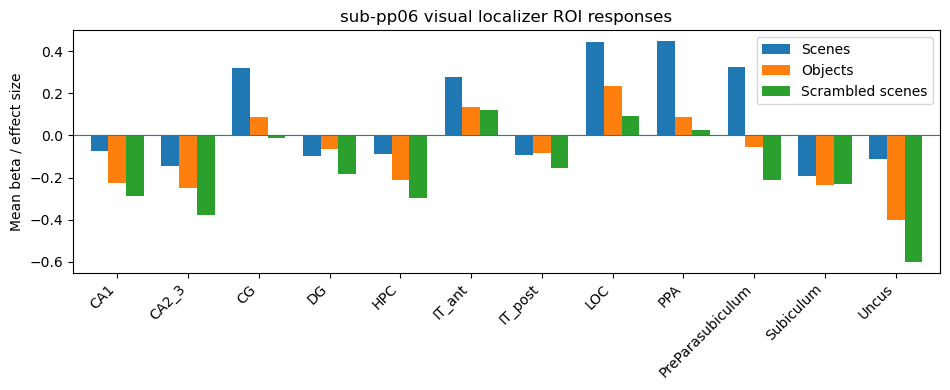

In [6]:
plot_df = results.pivot(index="roi", columns="condition", values="mean_beta")
plot_df = plot_df[[c for c in CONDITIONS.keys() if c in plot_df.columns]]

ax = plot_df.plot(kind="bar", figsize=(max(7, 0.8 * len(plot_df)), 4), width=0.75)
ax.axhline(0, linewidth=0.8)
ax.set_xlabel("")
ax.set_ylabel("Mean beta / effect size")
ax.set_title(f"sub-{format_subject(SUBJECT)} visual localizer ROI responses")
ax.legend(title="")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, f"sub-{format_subject(SUBJECT)}_panelB_roi_barplot.png")
plt.savefig(fig_path, dpi=200)
plt.show()

#print(f"Saved figure: {fig_path}")

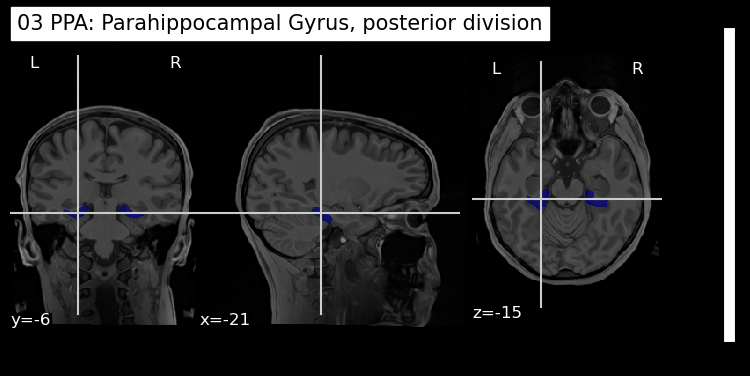

In [13]:
roi_code = "PPA"

plotting.plot_roi(
    roi_mask_path(ROIS[roi_code]),
    bg_img=os.path.join(PREPROC_DIR, f"sub-{format_subject(SUBJECT)}", "anat", f"sub-{format_subject(SUBJECT)}_desc-preproc_T1w.nii.gz"),
    title=f"{format_subject(SUBJECT)} {roi_code}: {os.path.basename(ROIS[roi_code])}",
    display_mode="ortho")